# 1.TIKTOK FAGRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [283]:
import pandas as pd
import networkx as nx
from itertools import combinations

# =====================================================
# LOAD TIKTOK GRAPH DATASET
# =====================================================

df = pd.read_csv(
    "../../data_preprocess/processed_data/graph_data/tiktok_graph.csv"
)

print("=" * 60)
print("TIKTOK GRAPH DATA")
print("=" * 60)

print(df.shape)

TIKTOK GRAPH DATA
(11887, 31)


In [125]:
print(df.head(1))

             post_id platform  hour_of_day  day_of_week  is_weekend  \
0  TIK20250419000000   TikTok            1            5           1   

       user_id  followers  account_age_days  verified    topic  ...   day_sin  \
0  user_426711        137               306         0  Finance  ... -0.974928   

    day_cos followers_log  has_media many_hashtags  long_content  \
0 -0.222521      4.927254          1             0             1   

   sentiment_intensity  high_toxicity  large_account popularity  
0                 0.63              0              0          0  

[1 rows x 32 columns]


In [284]:
import pandas as pd
import numpy as np
import time

overall_start = time.time()

# =====================================================
# 1. GENERATE NODES
# =====================================================
# Chuẩn hóa cột post_id thành Id để Gephi nhận diện nút
nodes_df = df.copy().rename(columns={"post_id": "Id"})
nodes_df["Label"] = nodes_df["Id"]

# Xuất file Node
nodes_df.to_csv("tiktok_node.csv", index=False, encoding='utf-8')

# =====================================================
# 2. GENERATE EDGES (MULTIMODAL HOMOPHILY)
# =====================================================
edges_list = []

# Sắp xếp theo thời gian/tuổi tài khoản để tạo logic nối "chuỗi" (Temporal Path)
sorted_df = df.sort_values(by=['account_age_days'], ascending=True)

# --- A. CÁC CỘT DẠNG VĂN BẢN (CATEGORICAL) ---
# Logic: Những bài có cùng Topic, cùng Location, cùng Language thì nối với nhau
cat_features = ['topic', 'location', 'language', 'media_type']

for feat in cat_features:
    if feat not in sorted_df.columns: continue
    print(f"Processing Categorical Homophily: {feat}...")
    
    for val, group in sorted_df.groupby(feat):
        # Bỏ qua nếu giá trị trống
        if pd.isna(val): continue
        
        ids = group['post_id'].values
        if len(ids) < 2: continue
        
        # Nối node i với i+1 (Path Linkage)
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.0, 
                "Relation": feat
            })

# --- B. CÁC CỘT DẠNG NHỊ PHÂN (BINARY 0/1) ---
# Logic: Chỉ nối nếu cả hai bài đều có thuộc tính đó (ví dụ: cùng verified)
bin_features = ['verified', 'has_media', 'is_weekend']

for feat in bin_features:
    if feat not in sorted_df.columns: continue
    print(f"Processing Binary Homophily: {feat}...")
    
    # Chỉ lấy những bài đăng có giá trị bằng 1
    active_group = sorted_df[sorted_df[feat] == 1]
    ids = active_group['post_id'].values
    
    if len(ids) < 2: continue
    for i in range(len(ids) - 1):
        edges_list.append({
            "Source": ids[i], 
            "Target": ids[i+1],
            "Weight": 1.0, 
            "Relation": feat
        })

# --- C. QUAN HỆ TÁC GIẢ (USER-ID) ---
# Logic: Cầu nối quan trọng nhất để liên kết các cụm chủ đề khác nhau
print("Processing User-Authorship Bridges...")
for user_id, group in sorted_df.groupby('user_id'):
    ids = group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 2.0, # Trọng số cao hơn vì quan hệ tác giả là quan hệ trực tiếp
                "Relation": "same_author"
            })

# =====================================================
# 3. CLEAN & EXPORT
# =====================================================
edges_df = pd.DataFrame(edges_list)

# Đảm bảo không bị lặp cạnh (Source < Target)
edges_df[['Source', 'Target']] = np.sort(edges_df[['Source', 'Target']], axis=1)
edges_df = edges_df.drop_duplicates(subset=['Source', 'Target', 'Relation'])
edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

# Xuất file Edge
edges_df.to_csv("tiktok_edge.csv", index=False, encoding='utf-8')

print(f"\n--- THÀNH PHẨM ---")
print(f"Nodes: {len(nodes_df):,}")
print(f"Edges: {len(edges_df):,}")
print(f"Time: {round(time.time() - overall_start, 2)}s")

Processing Categorical Homophily: topic...
Processing Categorical Homophily: location...
Processing Categorical Homophily: language...
Processing Categorical Homophily: media_type...
Processing Binary Homophily: verified...
Processing Binary Homophily: has_media...
Processing Binary Homophily: is_weekend...
Processing User-Authorship Bridges...

--- THÀNH PHẨM ---
Nodes: 11,887
Edges: 58,987
Time: 1.15s


In [285]:
import pandas as pd

graph_df = pd.read_csv(
    "tiktok-result-2.csv"
)

print("\n" + "=" * 60)
print("GRAPH FEATURES DATA")
print("=" * 60)

print(graph_df.shape)

print("\nColumns:")
print(graph_df.columns.tolist())


GRAPH FEATURES DATA
(11887, 38)

Columns:
['Id', 'Label', 'platform', 'hour_of_day', 'day_of_week', 'is_weekend', 'user_id', 'followers', 'account_age_days', 'verified', 'topic', 'language', 'content_length', 'media_type', 'num_hashtags', 'sentiment_category', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'toxicity_score', 'location', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'followers_log', 'has_media', 'many_hashtags', 'long_content', 'sentiment_intensity', 'high_toxicity', 'popularity', 'Degree', 'Authority', 'Hub', 'pageranks', 'modularity_class', 'eigencentrality']


In [286]:
# SELECT ONLY USEFUL GRAPH FEATURES (Dựa trên cột thực tế từ Gephi)
# =====================================================

graph_features = graph_df[[
    "Id",                
    "Degree",            
    "eigencentrality",
    "modularity_class",
    "pageranks"  
]]

# Đổi tên ID để đồng bộ với dataset gốc
graph_features = graph_features.rename(
    columns={
        "Id": "post_id"
    }
)

print("\nGraph Features Shape:")
print(graph_features.shape)
print("\nCác cột đặc trưng đồ thị đã chọn:")
print(graph_features.columns.tolist())


Graph Features Shape:
(11887, 5)

Các cột đặc trưng đồ thị đã chọn:
['post_id', 'Degree', 'eigencentrality', 'modularity_class', 'pageranks']


In [287]:
original_df = df.copy()

# =====================================================
# REMOVE DUPLICATES
# =====================================================

original_df = original_df.drop_duplicates(
    subset=["post_id"]
)

In [288]:
# MERGE POST_ID BACK TO TRAIN/TEST
# =====================================================
# We need mapping between rows
# =====================================================

# recreate metadata version
metadata_df = original_df.copy()

remove_cols = [
    
    "timestamp",
    "date",
    "platform",
    "likes",
    "shares",
    "comments",
    "views",
    "total_engagement",
    "engagement_rate_per_1k_followers",
    "viral_coefficient",
    "cross_platform_spread",
    "hours_since_post"
]

existing_remove_cols = [

    col for col in remove_cols
    if col in metadata_df.columns
]

metadata_df = metadata_df.drop(
    columns=existing_remove_cols
)


In [289]:
# =====================================================
# ONE-HOT ENCODING
# =====================================================

categorical_cols = [

    "topic",
    "language",
    "media_type",
    "sentiment_category",
    "location"
]

existing_categorical_cols = [

    col for col in categorical_cols
    if col in metadata_df.columns
]

metadata_df = pd.get_dummies(

    metadata_df,

    columns=existing_categorical_cols,

    drop_first=True
)


In [290]:
# LOAD FACEBOOK TRAIN / TEST
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/tiktok_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/tiktok_test.csv"
)

print("=" * 60)
print("METADATA DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATASETS
Train Shape: (9509, 57)
Test Shape : (2378, 57)


In [291]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

In [292]:
train_hybrid.head(1)

,post_id,hour_of_day,day_of_week,is_weekend,user_id,followers,account_age_days,verified,content_length,num_hashtags,...,location_Europe,location_North America,location_Oceania,location_South America,location_Unknown,popularity,Degree,eigencentrality,modularity_class,pageranks
0,TIK20250610108203,22,1,0,user_294276,9482,1321,0,114,3,...,0,1,0,0,0,1,9,0.578108,15,0.000093


In [293]:
# SAVE HYBRID DATASETS
# =====================================================

train_hybrid.to_csv(
    "tiktok_hybrid_train.csv",
    index=False
)

test_hybrid.to_csv(
    "tiktok_hybrid_test.csv",
    index=False
)

In [294]:
# =====================================================
# TIKTOK HYBRID MODEL
# METADATA + GRAPH FEATURES
# =====================================================

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [295]:
# LOAD HYBRID DATASETS
# =====================================================

train_df = pd.read_csv(
    "tiktok_hybrid_train.csv"
)

test_df = pd.read_csv(
    "tiktok_hybrid_test.csv"
)

print("=" * 60)
print("HYBRID DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

HYBRID DATASETS
Train Shape: (9509, 61)
Test Shape : (2378, 61)


In [296]:
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_df.columns
]

train_df = train_df.drop(
    columns=existing_drop_cols
)

test_df = test_df.drop(
    columns=existing_drop_cols
)

In [297]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_df.drop(
    columns=["popularity"]
)

y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=["popularity"]
)

y_test = test_df["popularity"]

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (9509, 58)
X_test Shape : (2378, 58)


In [298]:
# --- CODE XEM GIÁ TRỊ POPULARITY TẠI ĐÂY ---
print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TRAIN")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TEST")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


PHÂN BỔ LỚP TRONG TẬP TRAIN
popularity
0    7607
1    1902
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.997897
1    20.002103
Name: proportion, dtype: float64

PHÂN BỔ LỚP TRONG TẬP TEST
popularity
0    1902
1     476
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.983179
1    20.016821
Name: proportion, dtype: float64


In [299]:
# XGBOOST HYBRID MODEL (Dựa trên cấu trúc Baseline của bạn)
# =====================================================

# Tính toán tỉ lệ mất cân bằng (giữ nguyên như baseline để đồng bộ)
ratio = 7607 / 1902

model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,      # Quan trọng để xử lý mất cân bằng
    
    # THAM SỐ CỐT LÕI (Giữ nguyên để so sánh công bằng)
    n_estimators=500,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=1,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,

    # BỔ SUNG CHO HYBRID: Xử lý cột modularity_class
    # Giúp model hiểu các cột Category mà không cần One-Hot Encoding thủ công
    enable_categorical=True,
    tree_method='hist'           # Tăng tốc độ huấn luyện khi có nhiều đặc trưng
)

# Training model
# model_hybrid.fit(X_train_hybrid, y_train_hybrid)

In [300]:
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING HYBRID MODEL...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [301]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Get probability scores for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate precision-recall pairs
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate F1-score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Locate the threshold that yields the highest F1-score
best_threshold = thresholds[np.argmax(f1_scores)]

# Apply the optimal threshold to generate final predictions
y_pred = (y_prob >= best_threshold).astype(int)

In [302]:
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [303]:
# CLASSIFICATION REPORT
# =====================================================
from sklearn.metrics import classification_report

print("\n" + "=" * 60)
print("HYBRID MODEL CLASSIFICATION REPORT (METADATA + GRAPH)")
print("=" * 60)

# Thêm tham số digits=4 để ép mọi chỉ số về 4 chữ số thập phân
print(
    classification_report(
        y_test, 
        y_pred,
        digits=4
    )
)

# In ROC-AUC với định dạng 4 chữ số thập phân
print(f"ROC-AUC SCORE : {roc_auc:.4f}")
print("=" * 60)


HYBRID MODEL CLASSIFICATION REPORT (METADATA + GRAPH)
              precision    recall  f1-score   support

           0     0.9143    0.8754    0.8944      1902
           1     0.5745    0.6723    0.6196       476

    accuracy                         0.8347      2378
   macro avg     0.7444    0.7738    0.7570      2378
weighted avg     0.8463    0.8347    0.8394      2378

ROC-AUC SCORE : 0.8685


In [304]:
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[1665  237]
 [ 156  320]]


In [305]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                feature  importance
15        followers_log    0.132227
3             followers    0.123309
5              verified    0.059812
27           topic_Food    0.016471
44      media_type_Link    0.015548
23      topic_Education    0.015502
19  sentiment_intensity    0.015301
26        topic_Finance    0.014843
39       language_Hindi    0.014622
4      account_age_days    0.014620
55      eigencentrality    0.014486
9    sentiment_negative    0.014425
8    sentiment_positive    0.013998
57            pageranks    0.013882
51     location_Oceania    0.013683
25        topic_Fashion    0.013597
28         topic_Gaming    0.013549
11             hour_sin    0.013541
6        content_length    0.013428
32         topic_Sports    0.013330


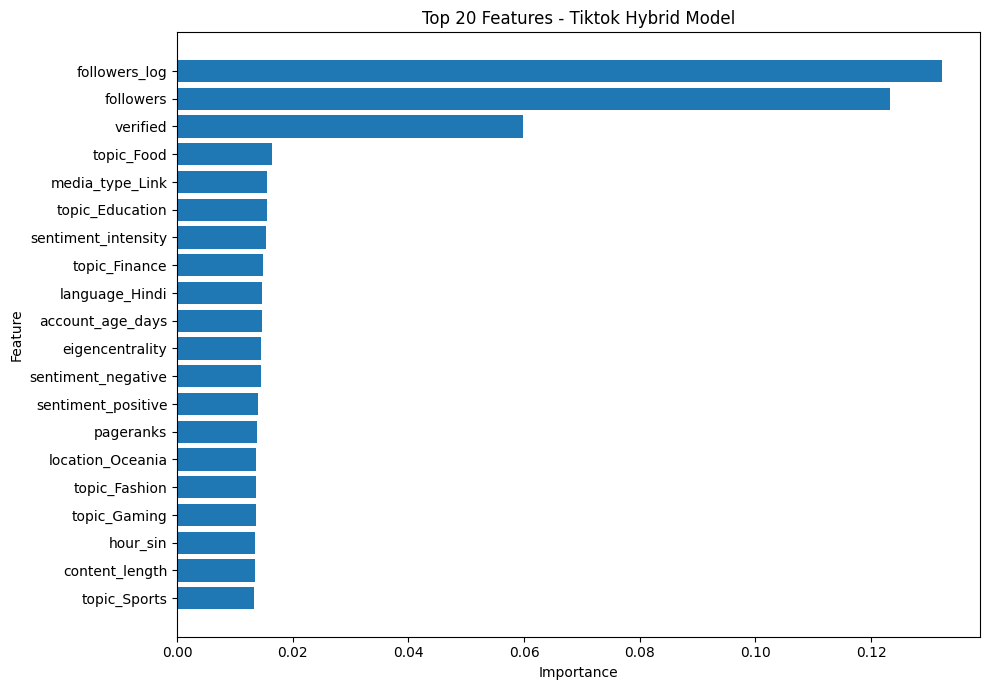

In [306]:
# PLOT TOP FEATURES
# =====================================================
import matplotlib.pyplot as plt

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Features - Tiktok Hybrid Model"
)

plt.tight_layout()

plt.show()

# 2. TIKTOK NODE2VEC

 GRAPH EMBEDDING

In [345]:
# LOAD GRAPH FEATURES FILE
# =====================================================
import pandas as pd

graph_df = pd.read_csv(
    "tiktok-result-2.csv"
)

print("=" * 60)
print("GRAPH DATA")
print("=" * 60)

print(graph_df.shape)


GRAPH DATA
(11887, 38)


In [346]:
# CREATE NETWORKX GRAPH
# =====================================================

G = nx.Graph()

# =====================================================
# ADD NODES
# =====================================================

for idx, row in graph_df.iterrows():

    G.add_node(
        row["Id"]
    )

# =====================================================
# CREATE EDGES
# =====================================================
# IMPORTANT:
# Need original graph edge list
# =====================================================

# If you exported edge list from Gephi:
# load it here

edges_df = pd.read_csv(
    "tiktok_edge.csv"
)

print("\nEdges Shape:")
print(edges_df.shape)

# =====================================================
# ADD EDGES
# =====================================================

for idx, row in edges_df.iterrows():

    source = row["Source"]
    target = row["Target"]

    # optional weight
    if "Weight" in edges_df.columns:

        G.add_edge(
            source,
            target,
            weight=row["Weight"]
        )

    else:

        G.add_edge(
            source,
            target
        )

print("\nGraph Created 🚀")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Edges Shape:
(58987, 4)

Graph Created 🚀
Nodes: 11887
Edges: 46375


In [347]:
# NODE2VEC
# =====================================================
from node2vec import Node2Vec


print("\n" + "=" * 60)
print("TRAINING NODE2VEC...")
print("=" * 60)

node2vec = Node2Vec(

    G,

    dimensions=16,

    walk_length=10,

    num_walks=30,

    workers=4,

    weight_key="weight",

    seed=42
)

model = node2vec.fit(

    window=5,

    min_count=1,

    batch_words=64
)

print("\nNode2Vec completed 🚀")



TRAINING NODE2VEC...


Computing transition probabilities:   0%|          | 0/11887 [00:00<?, ?it/s]


Node2Vec completed 🚀


In [348]:
# CREATE EMBEDDING DATAFRAME
# =====================================================

embeddings = []

for node in G.nodes():

    vector = model.wv[str(node)]

    row_data = {

        "post_id": node
    }

    # embedding dimensions
    for i in range(len(vector)):

        row_data[f"n2v_{i}"] = vector[i]

    embeddings.append(row_data)

embedding_df = pd.DataFrame(
    embeddings
)

print("\nEmbedding Shape:")
print(embedding_df.shape)


Embedding Shape:
(11887, 17)


In [349]:
# SAVE EMBEDDINGS
# =====================================================

embedding_df.to_csv(
    "tiktok_node2vec_embeddings.csv",
    index=False
)

print("\nNode2Vec embeddings saved 🚀")


Node2Vec embeddings saved 🚀


In [351]:
# FACEBOOK NODE2VEC HYBRID MODEL
# METADATA + NODE2VEC EMBEDDINGS
# =====================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt

In [352]:
# LOAD TRAIN / TEST DATA
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/tiktok_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/tiktok_test.csv"
)

print("=" * 60)
print("METADATA DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATA
Train Shape: (9509, 57)
Test Shape : (2378, 57)


In [353]:
#LOAD NODE2VEC EMBEDDINGS
# =====================================================

embedding_df = pd.read_csv(
    "tiktok_node2vec_embeddings.csv"
)

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

print("\nEmbedding Columns:")
print(embedding_df.columns.tolist())


NODE2VEC EMBEDDINGS
(11887, 17)

Embedding Columns:
['post_id', 'n2v_0', 'n2v_1', 'n2v_2', 'n2v_3', 'n2v_4', 'n2v_5', 'n2v_6', 'n2v_7', 'n2v_8', 'n2v_9', 'n2v_10', 'n2v_11', 'n2v_12', 'n2v_13', 'n2v_14', 'n2v_15']


In [354]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# CHECK MISSING VALUES
# =====================================================

print("\n" + "=" * 60)
print("MISSING EMBEDDINGS CHECK")
print("=" * 60)

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nTrain Missing:")

print(
    train_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

# =====================================================
# FILL MISSING EMBEDDINGS
# =====================================================

train_hybrid[embedding_cols] = train_hybrid[
    embedding_cols
].fillna(0)

test_hybrid[embedding_cols] = test_hybrid[
    embedding_cols
].fillna(0)

# =====================================================
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_hybrid.columns
]

train_hybrid = train_hybrid.drop(
    columns=existing_drop_cols
)

test_hybrid = test_hybrid.drop(
    columns=existing_drop_cols
)


MISSING EMBEDDINGS CHECK

Train Missing:
0

Test Missing:
0


In [355]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_hybrid.drop(
    columns=["popularity"]
)

y_train = train_hybrid["popularity"]

X_test = test_hybrid.drop(
    columns=["popularity"]
)

y_test = test_hybrid["popularity"]

print("\n" + "=" * 60)
print("FINAL DATA")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)



FINAL DATA
X_train: (9509, 70)
X_test : (2378, 70)


In [356]:
# =====================================================
# XGBOOST MODEL
# =====================================================

# Calculate class imbalance ratio
ratio = 7607 / 1902

# Initialize XGBoost with optimized parameters
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.8,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING NODE2VEC HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Training completed 🚀")

# =====================================================
# PREDICTIONS
# =====================================================
import numpy as np
from sklearn.metrics import precision_recall_curve

# Get probability scores for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate precision-recall pairs
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate F1-score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Locate the threshold that yields the highest F1-score
best_threshold = thresholds[np.argmax(f1_scores)]

# Apply the optimal threshold to generate final predictions
y_pred = (y_prob >= best_threshold).astype(int)

# =====================================================
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


TRAINING NODE2VEC HYBRID MODEL...
Training completed 🚀


In [357]:
# CLASSIFICATION REPORT
# =====================================================
from sklearn.metrics import classification_report

print("\n" + "=" * 60)
print("HYBRID MODEL CLASSIFICATION REPORT (METADATA)")
print("=" * 60)

# Thêm tham số digits=4 vào đây
report = classification_report(
    y_test, 
    y_pred, 
    digits=4
)

print(report)

# Đảm bảo ROC-AUC cũng đồng bộ 4 chữ số
print(f"ROC-AUC SCORE : {roc_auc:.4f}")
print("=" * 60)


HYBRID MODEL CLASSIFICATION REPORT (METADATA)
              precision    recall  f1-score   support

           0     0.9187    0.8375    0.8762      1902
           1     0.5202    0.7038    0.5982       476

    accuracy                         0.8108      2378
   macro avg     0.7194    0.7707    0.7372      2378
weighted avg     0.8389    0.8108    0.8206      2378

ROC-AUC SCORE : 0.8640


In [358]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                feature  importance
3             followers    0.120561
15        followers_log    0.101767
5              verified    0.060896
26        topic_Finance    0.016506
20        high_toxicity    0.016171
44      media_type_Link    0.015163
25        topic_Fashion    0.013245
40    language_Japanese    0.012979
4      account_age_days    0.012972
9    sentiment_negative    0.012878
29         topic_Health    0.012849
27           topic_Food    0.012478
42  language_Portuguese    0.012373
38      language_German    0.012218
55                n2v_1    0.012077
60                n2v_6    0.012026
57                n2v_3    0.011889
54                n2v_0    0.011763
58                n2v_4    0.011743
32         topic_Sports    0.011673


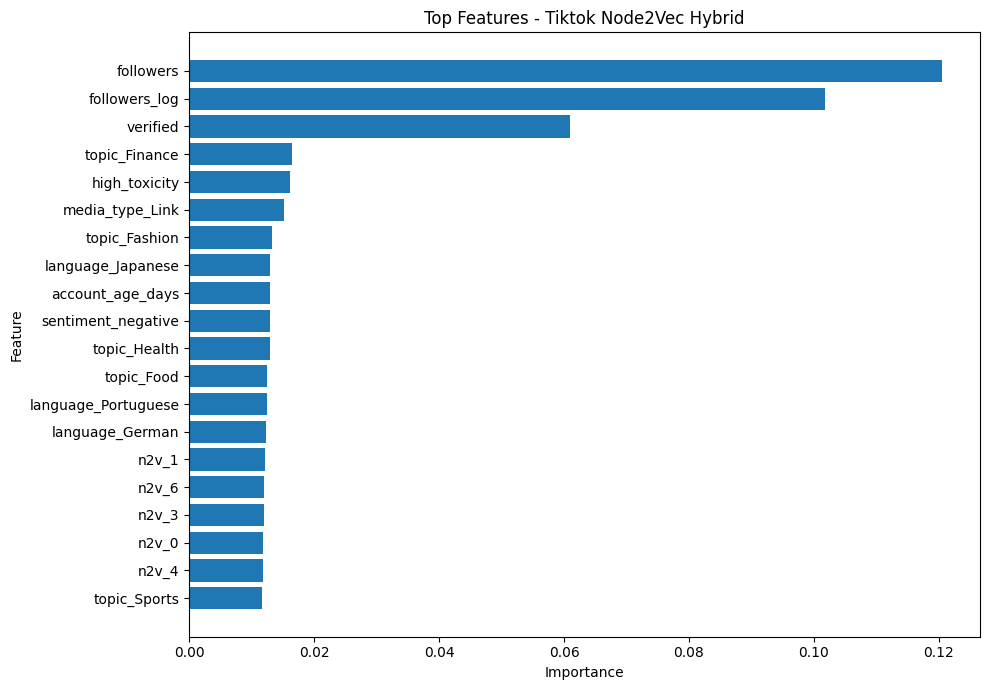

In [359]:
# =====================================================

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features - Tiktok Node2Vec Hybrid"
)

plt.tight_layout()

plt.show()

In [360]:
# 1. Xác định các cột n2v có Importance cao nhất từ kết quả mới của bạn
# Tôi chọn thêm n2v_9 và n2v_4 (vì chúng thường mạnh ở các lần chạy trước) để dự phòng
selected_n2v = ["n2v_1", "n2v_6", "n2v_3", "n2v_0", "n2v_4"]

# 2. Lọc embedding_df: Chỉ giữ lại ID và các cột đã chọn
# Các cột n2v_0, n2v_1, n2v_2... không có tên trong danh sách sẽ bị loại bỏ hoàn toàn
embedding_df = embedding_df[["post_id"] + selected_n2v]

print("--- Đã lọc Embedding ---")
print(f"Cột còn lại: {embedding_df.columns.tolist()}")
print(f"Số lượng dòng: {len(embedding_df)}")

--- Đã lọc Embedding ---
Cột còn lại: ['post_id', 'n2v_1', 'n2v_6', 'n2v_3', 'n2v_0', 'n2v_4']
Số lượng dòng: 11887


# 3. Tiktok graph + Node2vector

In [361]:
train_df = pd.read_csv(
    "tiktok_hybrid_train.csv"
)

test_df = pd.read_csv(
    "tiktok_hybrid_test.csv"
)

print("=" * 60)
print("GRAPH HYBRID DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# =====================================================
# LOAD NODE2VEC EMBEDDINGS
# =====================================================

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

# =====================================================
# CHECK EMBEDDING KEY
# =====================================================

print("\nEmbedding Columns:")
print(embedding_df.columns)

GRAPH HYBRID DATA
Train Shape: (9509, 61)
Test Shape : (2378, 61)

NODE2VEC EMBEDDINGS
(11887, 6)

Embedding Columns:
Index(['post_id', 'n2v_1', 'n2v_6', 'n2v_3', 'n2v_0', 'n2v_4'], dtype='object')


In [362]:
# MERGE NODE2VEC INTO TRAIN
# =====================================================

train_final = train_df.merge(

    embedding_df,

    on="post_id",

    how="left"
)

# =====================================================
# MERGE NODE2VEC INTO TEST
# =====================================================

test_final = test_df.merge(

    embedding_df,

    on="post_id",

    how="left"
)

print("\n" + "=" * 60)
print("AFTER MERGE")
print("=" * 60)

print("Train Shape:", train_final.shape)
print("Test Shape :", test_final.shape)



AFTER MERGE
Train Shape: (9509, 66)
Test Shape : (2378, 66)


In [363]:
# CHECK MISSING EMBEDDINGS
# =====================================================

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nMissing Train Embeddings:")

print(
    train_final[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nMissing Test Embeddings:")

print(
    test_final[
        embedding_cols
    ].isnull().sum().sum()
)

# =====================================================
# FILL MISSING VALUES
# =====================================================

train_final[embedding_cols] = train_final[
    embedding_cols
].fillna(0)

test_final[embedding_cols] = test_final[
    embedding_cols
].fillna(0)

# =====================================================
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_final.columns
]

train_final = train_final.drop(
    columns=existing_drop_cols
)

test_final = test_final.drop(
    columns=existing_drop_cols
)



Missing Train Embeddings:
0

Missing Test Embeddings:
0


In [364]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_final.drop(
    columns=["popularity"]
)

y_train = train_final["popularity"]

X_test = test_final.drop(
    columns=["popularity"]
)

y_test = test_final["popularity"]

print("\n" + "=" * 60)
print("FINAL FEATURE SPACE")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


FINAL FEATURE SPACE
X_train: (9509, 63)
X_test : (2378, 63)


In [365]:
# XGBOOST MODEL
# =====================================================

# Calculate class imbalance ratio
ratio = 7607 / 1902

# Initialize XGBoost with optimized parameters
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.8,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING FINAL TIKTOK HYBRID...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("\nTraining completed 🚀")

# =====================================================
# PREDICTIONS
# =====================================================

import numpy as np
from sklearn.metrics import precision_recall_curve

# Get probability scores for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate precision-recall pairs
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate F1-score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Locate the threshold that yields the highest F1-score
best_threshold = thresholds[np.argmax(f1_scores)]

# Apply the optimal threshold to generate final predictions
y_pred = (y_prob >= best_threshold).astype(int)


TRAINING FINAL TIKTOK HYBRID...

Training completed 🚀


In [366]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


In [278]:


# CLASSIFICATION REPORT
# =====================================================
from sklearn.metrics import classification_report

print("\n" + "=" * 60)
print("HYBRID MODEL CLASSIFICATION REPORT (METADATA)")
print("=" * 60)

# Thêm tham số digits=4 vào đây
report = classification_report(
    y_test, 
    y_pred, 
    digits=4
)

print(report)

# Đảm bảo ROC-AUC cũng đồng bộ 4 chữ số
print(f"ROC-AUC SCORE : {roc_auc:.4f}")
print("=" * 60)


HYBRID MODEL CLASSIFICATION REPORT (METADATA)
              precision    recall  f1-score   support

           0     0.9150    0.8712    0.8925      1902
           1     0.5679    0.6765    0.6174       476

    accuracy                         0.8322      2378
   macro avg     0.7414    0.7738    0.7550      2378
weighted avg     0.8455    0.8322    0.8375      2378

ROC-AUC SCORE : 0.8678


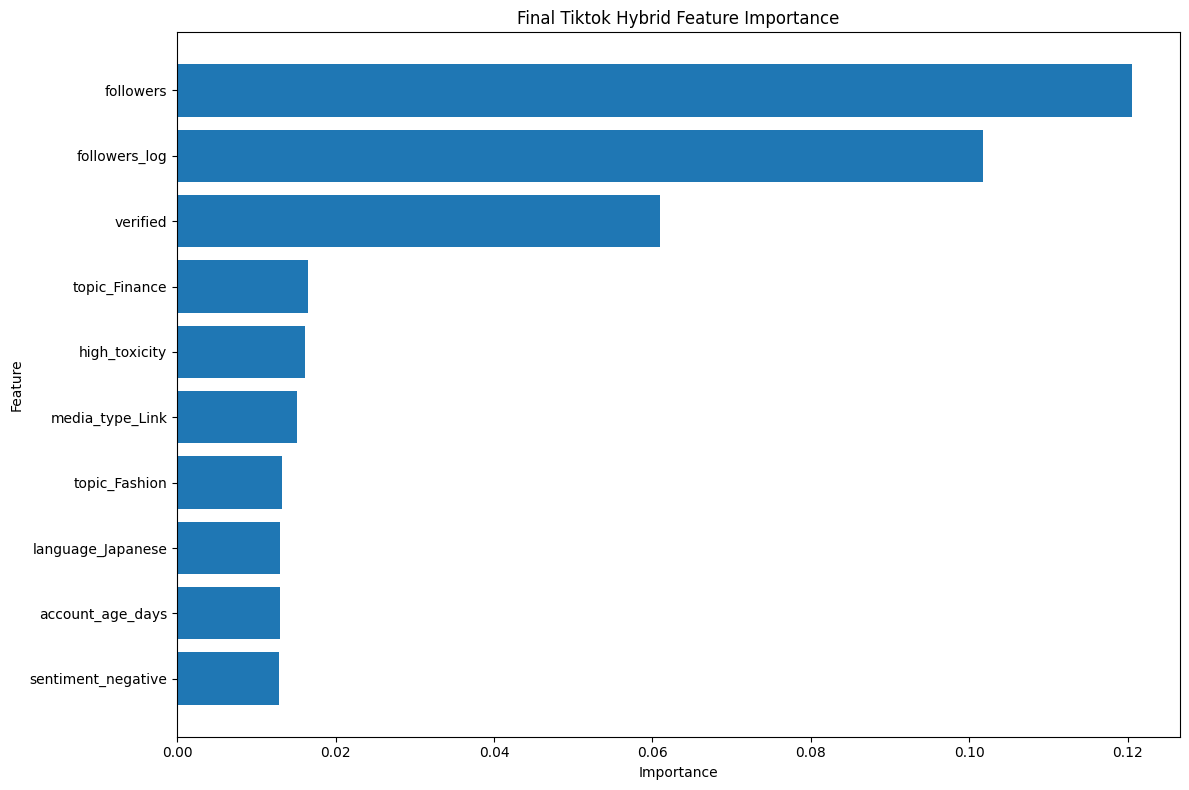

In [367]:
# PLOT FEATURE IMPORTANCE
# =====================================================

top_n = 10

plot_df = importance_df.head(top_n)

plt.figure(figsize=(12, 8))

plt.barh(

    plot_df["feature"][::-1],

    plot_df["importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Final Tiktok Hybrid Feature Importance"
)

plt.tight_layout()

plt.show()